In [2]:
import pandas as pd 
import matplotlib.pyplot  as plt
import seaborn as sns 
import numpy as np

In [3]:
retail_data = pd.read_csv("Sample - Superstore.csv",encoding="cp1252")
retail_data.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
retail_data.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [5]:
retail_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [6]:
retail_data.shape

(9994, 21)

In [7]:
retail_data["Order Date"]=pd.to_datetime(retail_data["Order Date"])

In [19]:

total_revenue=retail_data["Sales"].sum()
total_revenue

np.float64(2297200.8603)

In [20]:
avg_order=retail_data["Sales"].mean()
avg_order

np.float64(229.85800083049827)

In [21]:
total_profit=retail_data["Profit"].sum()
total_profit

np.float64(286397.0217)

In [22]:
top_product=retail_data.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_product

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

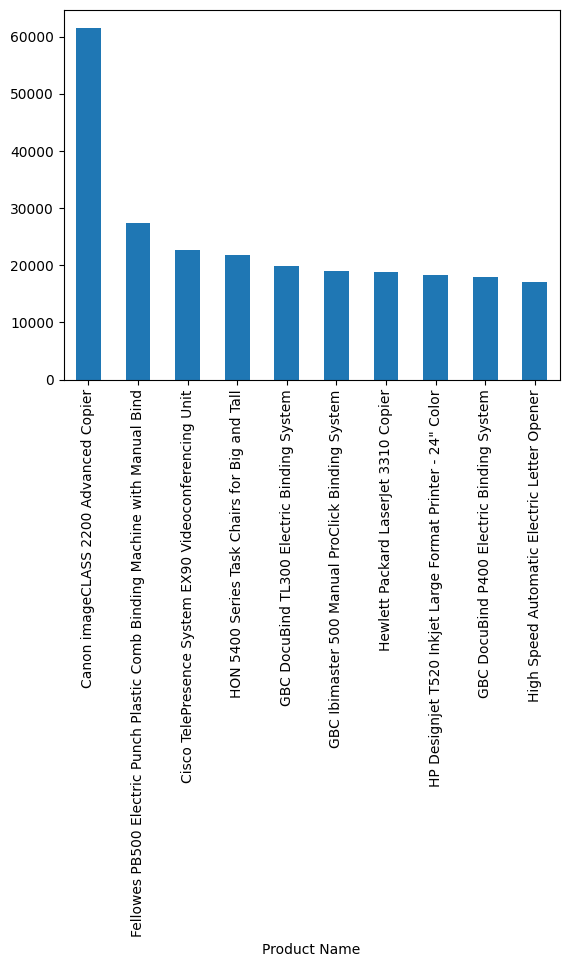

In [23]:
top_product.plot(kind="bar")
plt.show()

In [24]:
top_region=retail_data.groupby("Region")["Sales"].sum()
top_region

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

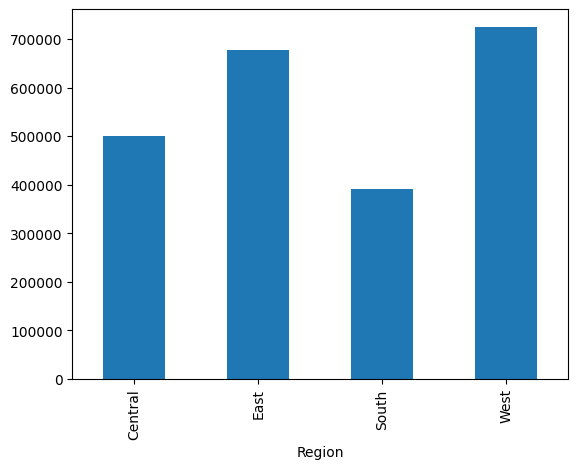

In [25]:
top_region.plot(kind="bar")
plt.show()

In [26]:
monthly_sales=retail_data.groupby(
    retail_data["Order Date"].dt.month
)["Sales"].sum()
monthly_sales

Order Date
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64

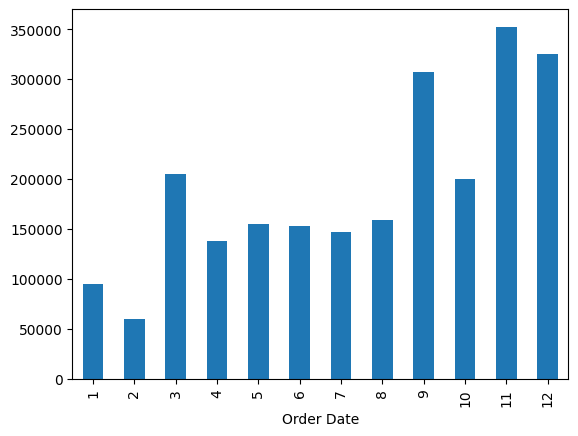

In [27]:
monthly_sales.plot(kind="bar")
plt.show()

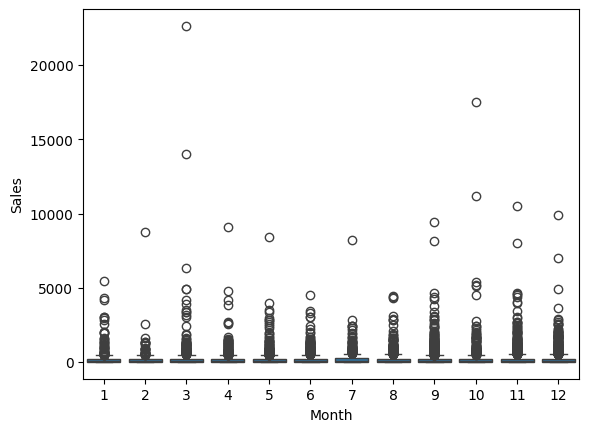

In [28]:
retail_data['Month'] = retail_data['Order Date'].dt.month

sns.boxplot(
    x='Month',
    y='Sales',
    data=retail_data
)

plt.show()

Text(0, 0.5, '\nSALES ANALYSIS REPORT\n\nTotal Revenue : $2,297,200.86\n\nTotal Profit : $286,397.02\n\nAverage Order Value : $229.86\n\nTop Region : Region\nCentral    501239.8908\nEast       678781.2400\nSouth      391721.9050\nWest       725457.8245\nName: Sales, dtype: float64\n\n')

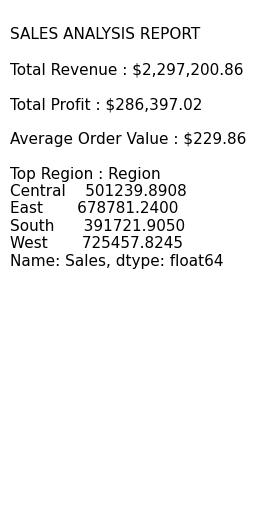

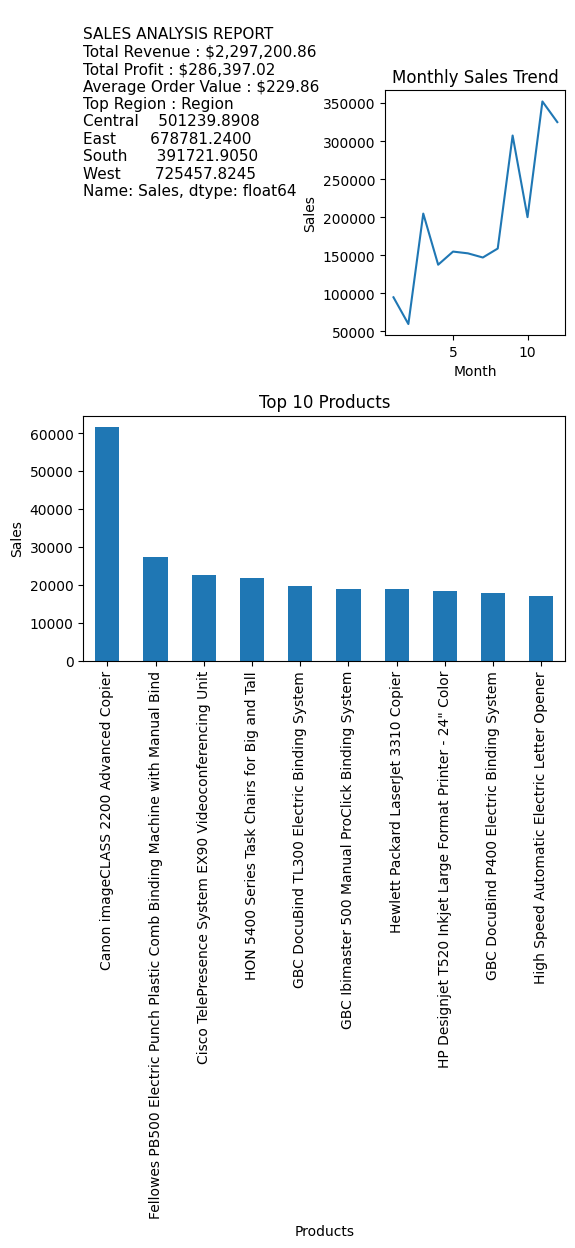

In [ ]:


fig = plt.figure(figsize=(6,12))
text = f"""
SALES ANALYSIS REPORT
Total Revenue : ${total_revenue:,.2f}
Total Profit : ${total_profit:,.2f}
Average Order Value : ${avg_order:,.2f}
Top Region : {top_region}
"""
plt.subplot(2,2,1)
plt.axis('off')
plt.text(0,0.5,text,fontsize=11)
# monthly sales
plt.subplot(2,2,2)
monthly_sales.plot()
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.subplot(2,1,2)
#top product
top_product.plot(kind='bar')
plt.title('Top 10 Products')
plt.xlabel('Products')
plt.ylabel('Sales')
#plot the data
plt.tight_layout()
# Export summary page
plt.savefig('Sales_One_Page_Report.png')
plt.show()